__Step 1: Import packages__

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler

__Step 2: Read Dataset__

In [ ]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


__Step 3: Sanity Check__

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
print(df.describe())

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  1.332271e+00  1.23709

In [6]:
print(f"Dataset Shape: {df.shape}")
print(f"Class Distribution:\n{df['Class'].value_counts(normalize=True)}")

Dataset Shape: (284807, 31)
Class Distribution:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


__Step 4: Null Value Detection__

In [8]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

<font color= 'red'>_No null values found in the dataset_</font>

__Step 5: Duplicates detection and handling__

In [11]:
df.duplicated().sum()

np.int64(1081)

In [13]:
df = df.drop_duplicates()

In [14]:
# Verify if duplicates have been dropped
df.duplicated().sum()

np.int64(0)

In [15]:
df.shape

(283726, 31)

__Step 6: Check for dataset imbalance__

In [16]:
#  target column is 'Class'
print("Transaction Counts:")
print(df['Class'].value_counts())

print("\nPercentage of Total:")
print(df['Class'].value_counts(normalize=True) * 100)

Transaction Counts:
Class
0    283253
1       473
Name: count, dtype: int64

Percentage of Total:
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


<font color='red'>Only 492 (or 0.172%) of transaction are fraudulent. That means the data is highly unbalanced with respect with target variable Class</font>

Visualising the imbalance

C:\Users\nitya\AppData\Local\Temp\ipykernel_12468\1851200102.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette=['#3498db', '#e74c3c'])


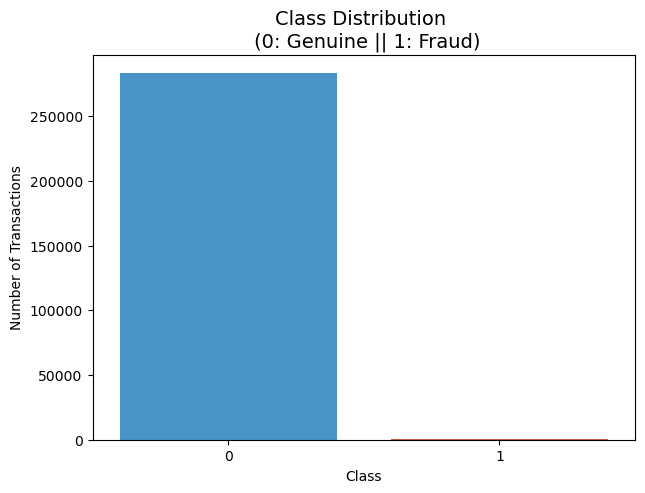

In [17]:
plt.figure(figsize=(7, 5))
sns.countplot(x='Class', data=df, palette=['#3498db', '#e74c3c'])
plt.title('Class Distribution \n (0: Genuine || 1: Fraud)', fontsize=14)
plt.ylabel('Number of Transactions')
plt.xlabel('Class')
plt.show()

__Step 7: Scaling the amount column__

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])

In [20]:
df = df.drop(['Amount'], axis=1)

In [21]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Class,Amount_scaled
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244200
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342584
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.158900
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.139886
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073813


__Step 8: Correlation Heatmap__

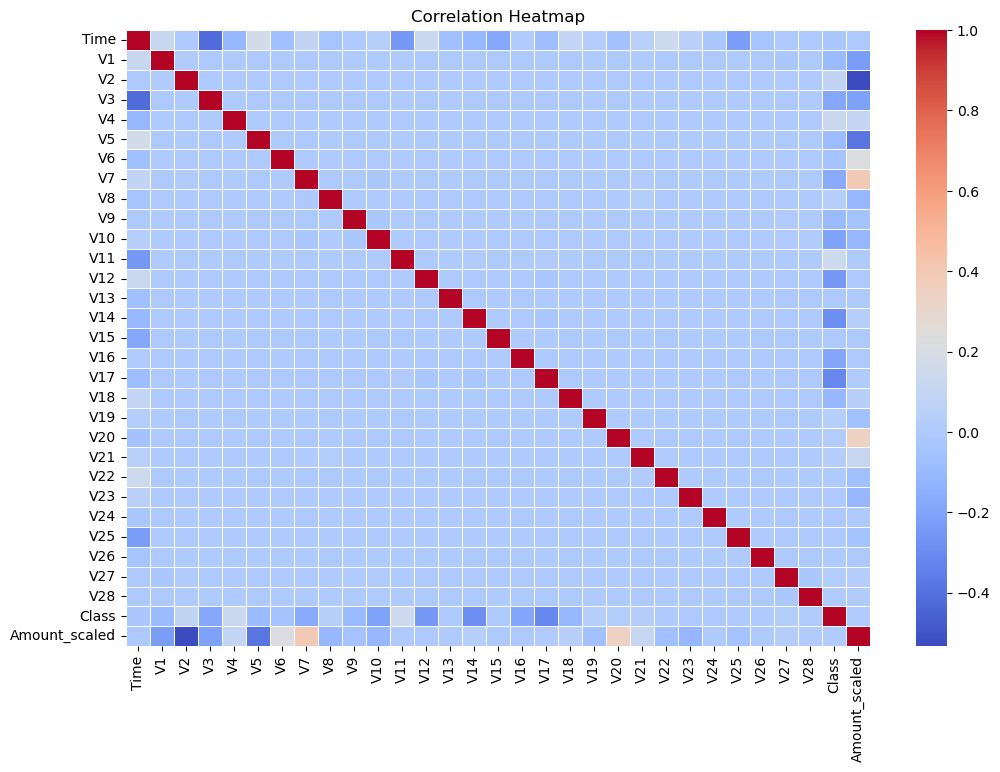

In [22]:
plt.figure(figsize=(12,8))
corr = df.corr()

sns.heatmap(corr, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Time column is being dropped since it has negligible correlation with the target variable
df = df.drop(['Time'], axis=1)

__Step 9: Separate Features and target__

X → all input features (what model learns from)

y → target variable (Class)

0 = Normal

1 = Fraud

In [24]:
X = df.drop('Class', axis=1)
y = df['Class']

In [25]:
X.shape
y.shape

(283726,)

__Step 10: Handling Class Imbalance using SMOTE = Synthetic Minority Over-sampling Technique__

In [26]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [27]:
y_resampled.value_counts()

Class
0    283253
1    283253
Name: count, dtype: int64

__Step 11: Train-Test Split__

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

Note:- <br>
-80% data → training <br>
-20% data → testing<br>
-stratify keeps class balance in both sets <Br>

In [29]:
#Verifying
X_train.shape, X_test.shape
y_train.value_counts(), y_test.value_counts()

(Class
 0    226602
 1    226602
 Name: count, dtype: int64,
 Class
 1    56651
 0    56651
 Name: count, dtype: int64)

__Step 12: Pre-Model Data Visualizations__

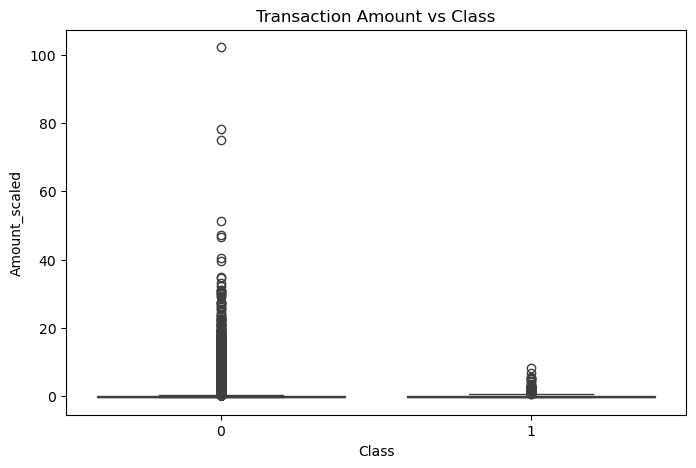

In [32]:
# 1. Fraud vs Amount Distribution
plt.figure(figsize=(8,5))
sns.boxplot(x='Class', y='Amount_scaled', data=df)
plt.title("Transaction Amount vs Class")
plt.show()

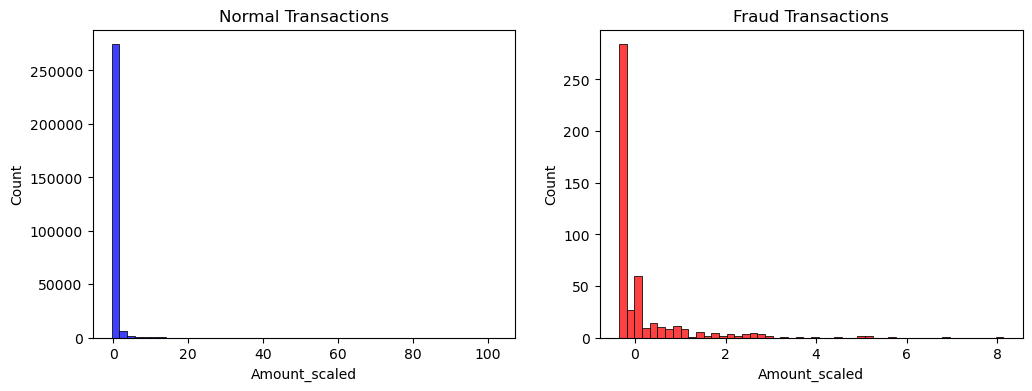

In [ ]:
# 2. Distribution of Amount (Fraud vs Normal)
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(
    df[df['Class']==0]['Amount_scaled'],
    ax=axes[0],
    color='blue',
    bins=50
)
axes[0].set_title("Normal Transactions")

sns.histplot(
    df[df['Class']==1]['Amount_scaled'],
    ax=axes[1],
    color='red',
    bins=50
)
axes[1].set_title("Fraud Transactions")

plt.show()

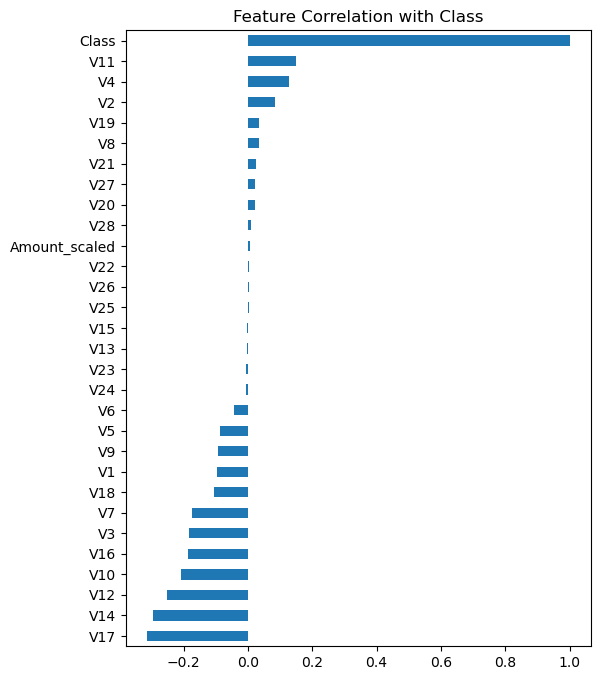

In [34]:
#  3. Correlation With Target
corr_with_class = df.corr()['Class'].sort_values()

plt.figure(figsize=(6,8))
corr_with_class.plot(kind='barh')
plt.title("Feature Correlation with Class")
plt.show()

__Step 13: Model Training__